# Method comparison — whole-domain (TVA) holdout

Re-plots **all methods + the CRC mean-shift baseline** on the TVA holdout task.
Reads the per-method results CSVs written by the training/eval notebooks and
scripts, concatenates whatever is available, and plots the headline metrics.

Inputs (`../../results/`), any subset that exists is used:

| CSV | Produced by | Label |
|-----|-------------|-------|
| `ood_cellina_{ds}_DEG_50.csv`     | `cellina_tva.ipynb`     | Cellina / Cellina-GAT |
| `ood_spatialprop_{ds}_DEG_50.csv` | `spatialprop_eval.py`   | SpatialProp |
| `ood_mintflow_{ds}_DEG_50.csv`    | (mintflow eval)         | MintFlow |
| `ood_baseline_{ds}_DEG_50.csv`    | `baseline_tva.ipynb`    | Mean shift (CRC) |

In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

## Config

In [3]:
DATASET_NAME = "crc"   # or "merfish"
n_deg = 50
RESULTS_DIR = "../../results"

# CSV -> we load whichever exist
CSV_CANDIDATES = {
    "cellina":     f"{RESULTS_DIR}/ood_cellina_{DATASET_NAME}_DEG_{n_deg}.csv",
    "spatialprop": f"{RESULTS_DIR}/ood_spatialprop_{DATASET_NAME}_DEG_{n_deg}.csv",
    "mintflow":    f"{RESULTS_DIR}/ood_mintflow_{DATASET_NAME}_DEG_{n_deg}.csv",
    "baseline":    f"{RESULTS_DIR}/ood_baseline_{DATASET_NAME}_DEG_{n_deg}.csv",
}

# Raw model_name in the CSVs -> display name
NAME_MAP = {
    "cellina-ood":     "Cellina",
    "cellina-gat-ood": "Cellina-GAT",
    "spatialprop-ood": "SpatialProp",
    "mintflow-ood":    "MintFlow",
    "baseline-ood":    "Mean shift (CRC)",
}

# Plot order (baseline last as the reference) and colours
MODEL_ORDER = ["Cellina", "Cellina-GAT", "SpatialProp", "MintFlow", "Mean shift (CRC)"]
PALETTE = {
    "Cellina":          "#8172B2",
    "Cellina-GAT":      "#4C72B0",
    "SpatialProp":      "skyblue",
    "MintFlow":         "green",
    "Mean shift (CRC)": "#b0b0b0",
}

# metric -> (axis label, direction)  direction: "up" = higher is better, "down" = lower is better
METRICS = {
    "spearman":          (r"Spearman $\rho$", "up"),
    "pearson":           (r"Pearson $r$",       "up"),
    "direction_match_k": ("Signed precision",   "up"),
    "edistance_pca_log": ("E-distance (PCA, log)", "down"),
    "mse_lfc":           ("MSE LFC",            "down"),
}

## Load results

In [4]:
frames = []
for name, path in CSV_CANDIDATES.items():
    if os.path.exists(path):
        df = pd.read_csv(path)
        frames.append(df)
        print(f"loaded {name:12s} ({len(df):5d} rows)  {path}")
    else:
        print(f"skip   {name:12s} (missing)        {path}")

assert frames, "No results CSVs found - run the method/baseline notebooks first."
combined_df = pd.concat(frames, ignore_index=True)

# Map to display names (keep original if unmapped)
combined_df["model_name"] = combined_df["model_name"].map(NAME_MAP).fillna(combined_df["model_name"])

present = [m for m in MODEL_ORDER if m in set(combined_df["model_name"].unique())]
# append any unmapped/extra models so nothing is silently dropped
present += [m for m in combined_df["model_name"].unique() if m not in present]
print("\nmodels present:", present)
combined_df["model_name"].value_counts()

loaded cellina      (   25 rows)  ../../results/ood_cellina_crc_DEG_50.csv
loaded spatialprop  (   25 rows)  ../../results/ood_spatialprop_crc_DEG_50.csv
loaded mintflow     (   25 rows)  ../../results/ood_mintflow_crc_DEG_50.csv
loaded baseline     (   50 rows)  ../../results/ood_baseline_crc_DEG_50.csv

models present: ['Cellina', 'SpatialProp', 'MintFlow', 'Mean shift (CRC)']


model_name
Mean shift (CRC)    50
Cellina             25
SpatialProp         25
MintFlow            25
Name: count, dtype: int64

## Summary table

Mean of each metric per method (across slides x holdout cell types).

In [5]:
summary_df = (
    combined_df.groupby("model_name")[list(METRICS)]
    .mean()
    .reindex(present)
)
summary_df

,spearman,pearson,direction_match_k,edistance_pca_log,mse_lfc
model_name,,,,,
Cellina,0.575748,0.608725,0.2472,11.141654,6.684504
SpatialProp,0.461328,0.555410,0.0968,26.661065,34.530063
MintFlow,0.623633,0.723452,0.2384,13.028572,1.926583
Mean shift (CRC),0.624323,0.611216,0.3092,32.423544,42.876613


## Plot

One panel per metric (independent x-axes because the scales differ). Bars are
the mean across slides x holdout cell types; error bars are the standard error.
Arrows in the titles indicate whether higher (↑) or lower (↓) is better.

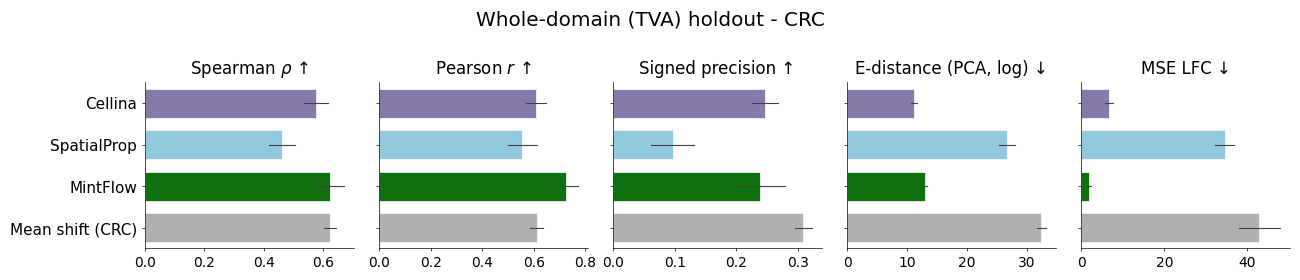

In [6]:
mpl.rcParams.update({
    "font.size": 12,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
    "legend.title_fontsize": 11,
    "axes.linewidth": 0.5,
    "xtick.major.width": 0.5,
    "ytick.major.width": 0.5,
    "xtick.major.size": 2,
    "ytick.major.size": 2,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

metric_keys = list(METRICS)
n = len(metric_keys)
fig, axes = plt.subplots(1, n, figsize=(2.6 * n, 2.6), sharey=True)
if n == 1:
    axes = [axes]

for i, (ax, metric) in enumerate(zip(axes, metric_keys)):
    label, direction = METRICS[metric]
    arrow = "↑" if direction == "up" else "↓"
    sns.barplot(
        data=combined_df,
        y="model_name",
        x=metric,
        hue="model_name",
        order=present,
        hue_order=present,
        palette=PALETTE,
        legend=False,
        orient="h",
        errorbar="se",
        err_kws={"linewidth": 0.8},
        width=0.7,
        ax=ax,
        linewidth=0.5,
        edgecolor="white",
    )
    sns.despine(ax=ax)
    ax.set_title(f"{label} {arrow}")
    ax.set_xlabel("")
    ax.set_ylabel("")

fig.suptitle(f"Whole-domain (TVA) holdout - {DATASET_NAME.upper()}", y=1.04)
plt.tight_layout(pad=0.6)
plt.savefig(f"compare_methods_tva_{DATASET_NAME}.svg", dpi=300, bbox_inches="tight")
plt.show()